In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname,filename))

In [3]:
df_train = pd.read_csv("./twitter_training.csv")
df_val = pd.read_csv("./twitter_validation.csv")

In [4]:
df_train

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
...,...,...,...,...
74676,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74677,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74678,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74679,9200,Nvidia,Positive,Just realized between the windows partition of...


In [5]:
df_val

,3364,Facebook,Irrelevant,"I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣"
0,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
2,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,4433,Google,Neutral,Now the President is slapping Americans in the...
4,6273,FIFA,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...
...,...,...,...,...
994,4891,GrandTheftAuto(GTA),Irrelevant,⭐️ Toronto is the arts and culture capital of ...
995,4359,CS-GO,Irrelevant,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...
996,2652,Borderlands,Positive,Today sucked so it’s time to drink wine n play...
997,8069,Microsoft,Positive,Bought a fraction of Microsoft today. Small wins.


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [7]:
df_train = df_train.rename(columns={'2401': 'ID', 'Borderlands': 'platform', 'Positive': 'sentimen', 'im getting on borderlands and i will murder you all ,': 'text'})
df_val = df_val.rename(columns={'3364': 'ID', 'Facebook': 'platform', 'Irrelevant': 'sentimen', 'I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣': 'text'})


In [8]:
df_train

,ID,platform,sentimen,text
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
...,...,...,...,...
74676,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74677,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74678,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74679,9200,Nvidia,Positive,Just realized between the windows partition of...


In [9]:
print(df_train["sentimen"].value_counts())
print(df_val["sentimen"].value_counts())

sentimen
Negative      22542
Positive      20831
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64
sentimen
Neutral       285
Positive      277
Negative      266
Irrelevant    171
Name: count, dtype: int64


In [10]:
print("Platform Counts - Training")
print(df_train["platform"].value_counts())
print(20*"==")
print("Platform Counts - Validation")
print(df_val["platform"].value_counts())

Platform Counts - Training
platform
Microsoft                            2400
MaddenNFL                            2400
TomClancysRainbowSix                 2400
LeagueOfLegends                      2394
CallOfDuty                           2394
Verizon                              2382
CallOfDutyBlackopsColdWar            2376
ApexLegends                          2376
Facebook                             2370
WorldOfCraft                         2364
Dota2                                2364
NBA2K                                2352
TomClancysGhostRecon                 2346
Battlefield                          2346
FIFA                                 2340
Overwatch                            2334
Xbox(Xseries)                        2334
johnson&johnson                      2328
Amazon                               2316
HomeDepot                            2310
PlayStation5(PS5)                    2310
CS-GO                                2304
Cyberpunk2077                        230

In [11]:
df_train = df_train.drop(["ID", "platform"],axis=1)
df_val = df_val.drop(["ID", "platform"],axis=1)

In [12]:
print(f"Rows: {df_train.shape[0]}, Columns: {df_train.shape[1]}")
print(f"DUPLICATES: {df_train.duplicated().sum()}")
print(f"missing data: {sum(df_train.isna().sum())}\n")
print("="*20)
print(f"Rows: {df_val.shape[0]}, Columns: {df_val.shape[1]}")
print(f"DUPLICATES: {df_val.duplicated().sum()}")
print(f"missing data: {sum(df_val.isna().sum())}")

Rows: 74681, Columns: 2
DUPLICATES: 4909
missing data: 686

Rows: 999, Columns: 2
DUPLICATES: 1
missing data: 0


In [13]:
kolom1=len(df_train.columns)
for i in range (0, kolom1):
  df_train=df_train[df_train.iloc[:,i]!='?']
  df_train=df_train[df_train.iloc[:,i]!='']
  df_train=df_train[~df_train.iloc[:,i].isna()]
df_train.info()
df_train.drop_duplicates(keep= 'first',inplace = True)

kolom=len(df_val.columns)
for i in range (0, kolom):
  df_val=df_val[df_val.iloc[:,i]!='?']
  df_val=df_val[df_val.iloc[:,i]!='']
  df_val=df_val[~df_val.iloc[:,i].isna()]
df_val.info()
df_val.drop_duplicates(keep= 'first',inplace = True)

print(f"Rows: {df_train.shape[0]}, Columns: {df_train.shape[1]}")
print(f"Duplicates: {df_train.duplicated().sum()}") 
print(f"missing data: {sum(df_train.isna().sum())}")

print(20*"==")

print(f"Rows: {df_val.shape[0]}, Columns: {df_val.shape[1]}")
print(f"Duplicates: {df_val.duplicated().sum()}") 
print(f"missing data: {sum(df_val.isna().sum())}")

<class 'pandas.core.frame.DataFrame'>
Index: 73995 entries, 0 to 74680
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sentimen  73995 non-null  object
 1   text      73995 non-null  object
dtypes: object(2)
memory usage: 1.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sentimen  999 non-null    object
 1   text      999 non-null    object
dtypes: object(2)
memory usage: 15.7+ KB
Rows: 69768, Columns: 2
Duplicates: 0
missing data: 0
Rows: 998, Columns: 2
Duplicates: 0
missing data: 0


In [14]:
!pip install emoji
import re
import string
import emoji
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

# Pastikan resource NLTK terunduh
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')           # kalau belum pernah diunduh
nltk.download('omw-1.4')           # opsional tapi sering diperlukan
nltk.download('punkt')             # untuk tokenisasi, jika kamu pakai word_tokenize()

# Inisialisasi
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Kamus singkatan umum (bisa diperluas)
abbreviation_map = {
    "u": "you",
    "ur": "your",
    "r": "are",
    "btw": "by the way",
    "idk": "i do not know",
    "imo": "in my opinion",
    "imho": "in my humble opinion",
    "lol": "laughing out loud",
    "omg": "oh my god",
    "thx": "thanks",
    "pls": "please",
    "plz": "please",
    "dont": "do not",
    "cant": "cannot",
    "wont": "will not",
    "ive": "i have",
    "ill": "i will",
    "didnt": "did not",
    "doesnt": "does not",
    "isnt": "is not",
    "wasnt": "was not",
    "havent": "have not",
    "shouldnt": "should not",
    "couldnt": "could not",
    "wouldnt": "would not",
}

def get_wordnet_pos(word):
    """
    Helper function: 
    Mengubah POS tag (part-of-speech) menjadi format yang bisa dipakai lemmatizer.
    """
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {
        'J': wordnet.ADJ,
        'N': wordnet.NOUN,
        'V': wordnet.VERB,
        'R': wordnet.ADV
    }
    return tag_dict.get(tag, wordnet.NOUN)


def preprocess_text(text):
    """
    Function for text preprocessing for English sentiment analysis.
    Includes:
      - lowercase
      - emoji handling
      - URL and number removal
      - punctuation removal
      - short form expansion
      - stopword removal
      - lemmatization
    """

    # Ensure input is string
    if not isinstance(text, str):
        text = str(text)

    # Lowercase
    text = text.lower()

    # Replace emojis with text description
    text = emoji.demojize(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Expand common short forms
    words = text.split()
    expanded_words = [abbreviation_map.get(w, w) for w in words]
    text = ' '.join(expanded_words)

    # Tokenize and remove stopwords + lemmatize
    filtered_words = []
    for word in text.split():
        if word not in stop_words:
            pos = get_wordnet_pos(word)
            lemma = lemmatizer.lemmatize(word, pos)
            filtered_words.append(lemma)

    # Join cleaned text
    processed_text = ' '.join(filtered_words)

    # Clean extra whitespace
    processed_text = re.sub(r'\s+', ' ', processed_text).strip()

    return processed_text

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\leeyu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\leeyu\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\leeyu\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\leeyu\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\leeyu\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\leeyu\AppData\Roaming\nltk

In [15]:
df_train['clean_text'] = df_train['text'].apply(preprocess_text)

print(df_train[['text','clean_text']])

                                                    text  \
0      I am coming to the borders and I will kill you...   
1      im getting on borderlands and i will kill you ...   
2      im coming on borderlands and i will murder you...   
3      im getting on borderlands 2 and i will murder ...   
4      im getting into borderlands and i can murder y...   
...                                                  ...   
74676  Just realized that the Windows partition of my...   
74677  Just realized that my Mac window partition is ...   
74678  Just realized the windows partition of my Mac ...   
74679  Just realized between the windows partition of...   
74680  Just like the windows partition of my Mac is l...   

                                              clean_text  
0                                       come border kill  
1                                 im get borderland kill  
2                              im come borderland murder  
3                               im get bord

In [16]:
df_train

,sentimen,text,clean_text
0,Positive,I am coming to the borders and I will kill you...,come border kill
1,Positive,im getting on borderlands and i will kill you ...,im get borderland kill
2,Positive,im coming on borderlands and i will murder you...,im come borderland murder
3,Positive,im getting on borderlands 2 and i will murder ...,im get borderland murder
4,Positive,im getting into borderlands and i can murder y...,im get borderland murder
...,...,...,...
74676,Positive,Just realized that the Windows partition of my...,realize window partition mac like year behind ...
74677,Positive,Just realized that my Mac window partition is ...,realize mac window partition year behind nvidi...
74678,Positive,Just realized the windows partition of my Mac ...,realize window partition mac year behind nvidi...
74679,Positive,Just realized between the windows partition of...,realize window partition mac like year behind ...


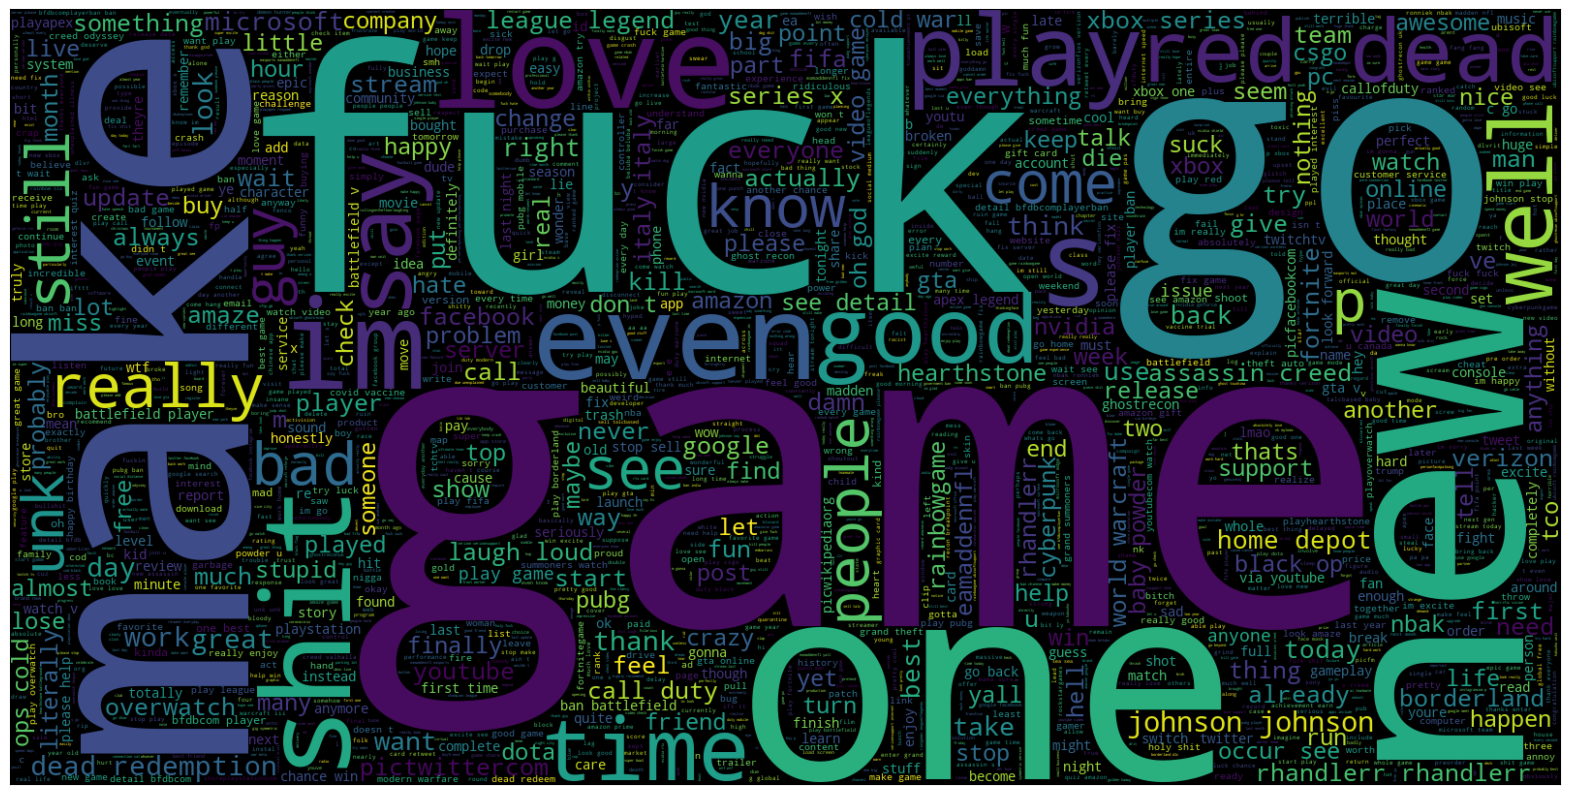

In [21]:
!pip install wordcloud
import matplotlib.pyplot as plt
from wordcloud import WordCloud,STOPWORDS
plt.figure(figsize=(20, 20))
wc = WordCloud(max_words=2000, width=1600, height=800, stopwords=STOPWORDS).generate(' '.join(df_train['clean_text']))
plt.imshow(wc, interpolation='bilinear')
plt.xticks([])
plt.yticks([])
plt.show()

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

tfidf = TfidfVectorizer(max_features=1700, ngram_range=(1,2))

In [23]:
df_val['clean_text'] = df_val['text'].apply(preprocess_text)

print("Kolom df_val setelah preprocessing:")
print(df_val[['text', 'clean_text']].head())

Kolom df_val setelah preprocessing:
                                                text  \
0  BBC News - Amazon boss Jeff Bezos rejects clai...   
1  @Microsoft Why do I pay for WORD when it funct...   
2  CSGO matchmaking is so full of closet hacking,...   
3  Now the President is slapping Americans in the...   
4  Hi @EAHelp I’ve had Madeleine McCann in my cel...   

                                          clean_text  
0  bbc news amazon bos jeff bezos reject claim co...  
1  microsoft pay word function poorly samsungus c...  
2  csgo matchmaking full closet hack truly awful ...  
3  president slap american face really commit unl...  
4  hi eahelp i’ve madeleine mccann cellar past ye...  


In [24]:
X_train = tfidf.fit_transform(df_train["clean_text"])
X_test = tfidf.transform(df_val["clean_text"])

y_train = df_train["sentimen"]
y_test = df_val["sentimen"]

In [25]:
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score, f1_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import inspect

def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Evaluasi model klasifikasi multi-class:
      - ROC & AUC (macro)
      - Akurasi
      - F1-score (macro)
      - ROC Curve Plot
    Dapat digunakan untuk SVM, Random Forest, Logistic Regression, dll.
    """

    # Prediksi label
    y_pred = model.predict(X_test)

    # Coba ambil skor probabilitas atau decision function
    if hasattr(model, "decision_function"):
        decision_scores = model.decision_function(X_test)
    elif hasattr(model, "predict_proba"):
        decision_scores = model.predict_proba(X_test)
    else:
        raise ValueError(f"Model {model_name} tidak mendukung ROC (butuh decision_function atau predict_proba)")

    # Binarisasi label untuk ROC multi-class
    y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
    n_classes = y_test_bin.shape[1]

    # Hitung ROC curve dan AUC untuk tiap kelas
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], decision_scores[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # AUC rata-rata (macro)
    roc_auc["macro"] = roc_auc_score(y_test_bin, decision_scores, average="macro", multi_class="ovr")

    # Akurasi dan F1-score
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    print(f"======= Evaluasi Klasifikasi {model_name} =======")
    print(f"Akurasi Klasifikasi     : {accuracy * 100:.2f}%")
    print(f"F-measure (macro avg)   : {f1:.3f}")
    print(f"AUC rata-rata (macro)   : {roc_auc['macro']:.3f}")
    print("=" * 45)

    # Plot ROC Curve
    plt.figure(figsize=(8, 6))
    colors = ['blue', 'green', 'orange', 'red', 'purple', 'brown']

    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    # Garis diagonal (baseline)
    plt.plot([0, 1], [0, 1], 'k--', lw=1)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for Multi-Class {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    return {
        "model": model_name,
        "accuracy": accuracy,
        "f1_macro": f1,
        "auc_macro": roc_auc["macro"]
    }

In [26]:
# Initialize and train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Accuracy: 0.6843687374749499
Classification Report:
               precision    recall  f1-score   support

  Irrelevant       0.68      0.57      0.62       171
    Negative       0.64      0.80      0.71       266
     Neutral       0.74      0.61      0.67       285
    Positive       0.69      0.72      0.71       276

    accuracy                           0.68       998
   macro avg       0.69      0.68      0.68       998
weighted avg       0.69      0.68      0.68       998



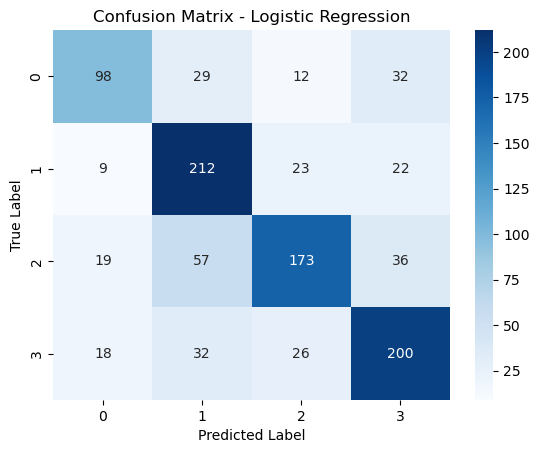

In [27]:
y_predlr = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_predlr))
print("Classification Report:\n", classification_report(y_test, y_predlr))

cm = confusion_matrix(y_test, y_predlr)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

======= Evaluasi Klasifikasi Logistic Regression =======
Akurasi Klasifikasi     : 68.44%
F-measure (macro avg)   : 0.677
AUC rata-rata (macro)   : 0.883


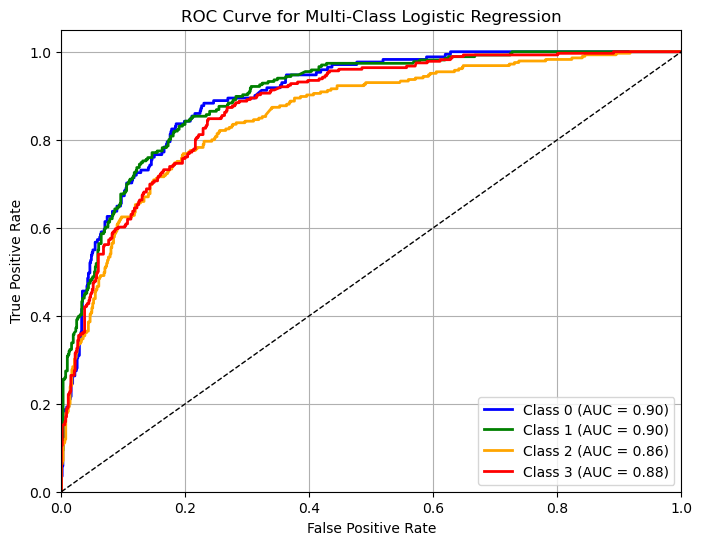

In [28]:
lr_results = evaluate_model(model, X_test, y_test, model_name="Logistic Regression")

In [29]:
new_text = ["This is a good product"]

# Preprocessing dulu jika diperlukan, lalu transform
X_new = tfidf.transform(new_text)

# Prediksi sentimen
pred = model.predict(X_new)
print("Hasil Prediksi:", pred[0])

Hasil Prediksi: Positive


In [30]:
new_text = ["good"]

# Preprocessing dulu jika diperlukan, lalu transform
X_new = tfidf.transform(new_text)

# Prediksi sentimen
pred = model.predict(X_new)
print("Hasil Prediksi:", pred[0])

Hasil Prediksi: Positive


Accuracy: 0.5280561122244489
Classification Report:
               precision    recall  f1-score   support

  Irrelevant       0.86      0.04      0.07       171
    Negative       0.42      0.91      0.58       266
     Neutral       0.84      0.35      0.50       285
    Positive       0.60      0.64      0.62       276

    accuracy                           0.53       998
   macro avg       0.68      0.49      0.44       998
weighted avg       0.67      0.53      0.48       998



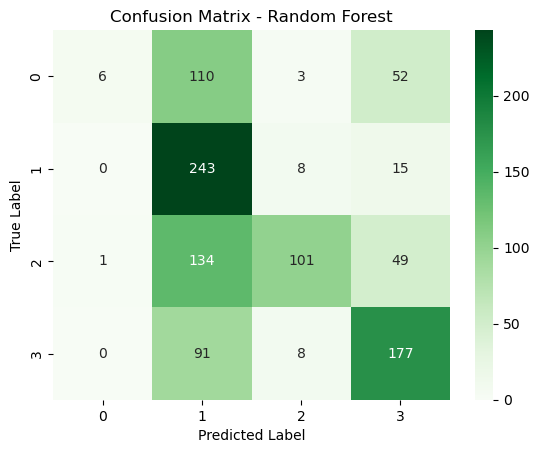

======= Evaluasi Klasifikasi Random Forest =======
Akurasi Klasifikasi     : 52.81%
F-measure (macro avg)   : 0.441
AUC rata-rata (macro)   : 0.858


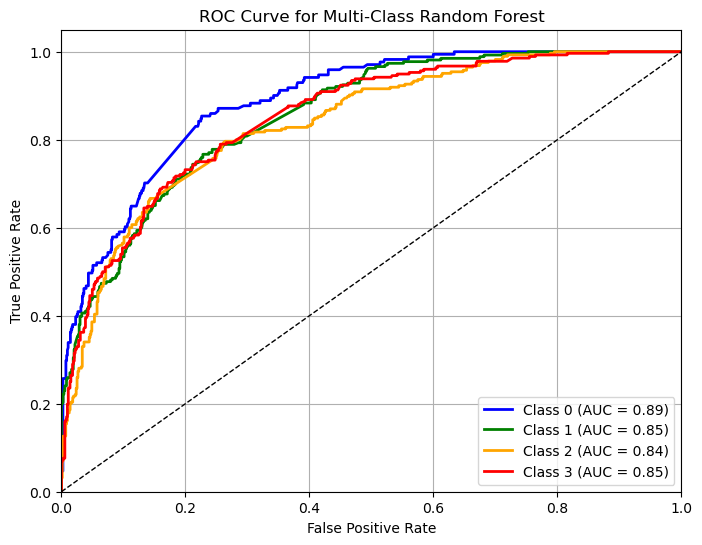

In [31]:
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,       
    max_depth=20,          
    min_samples_split=5,    
    min_samples_leaf=2,     
    random_state=42,        
    n_jobs=-1               
)

# Training model
rf_model.fit(X_train, y_train)

# Prediksi
y_pred_rf = rf_model.predict(X_test)

# Evaluasi
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Evaluasi lengkap dengan ROC Curve
rf_results = evaluate_model(rf_model, X_test, y_test, model_name="Random Forest")

In [32]:
new_text = ["this is bad product"]

# Preprocessing dulu jika diperlukan, lalu transform
X_new = tfidf.transform(new_text)

# Prediksi sentimen
pred = model.predict(X_new)
print("Hasil Prediksi:", pred[0])

Hasil Prediksi: Negative


In [33]:
new_text = ["good"]

# Preprocessing dulu jika diperlukan, lalu transform
X_new = tfidf.transform(new_text)

# Prediksi sentimen
pred = model.predict(X_new)
print("Hasil Prediksi:", pred[0])

Hasil Prediksi: Positive


[LibLinear]Calibrating probabilities...
[LibLinear][LibLinear][LibLinear]Accuracy: 0.594188376753507
Classification Report:
               precision    recall  f1-score   support

  Irrelevant       0.85      0.10      0.18       171
    Negative       0.51      0.89      0.65       266
     Neutral       0.72      0.51      0.59       285
    Positive       0.62      0.71      0.66       276

    accuracy                           0.59       998
   macro avg       0.68      0.55      0.52       998
weighted avg       0.66      0.59      0.56       998



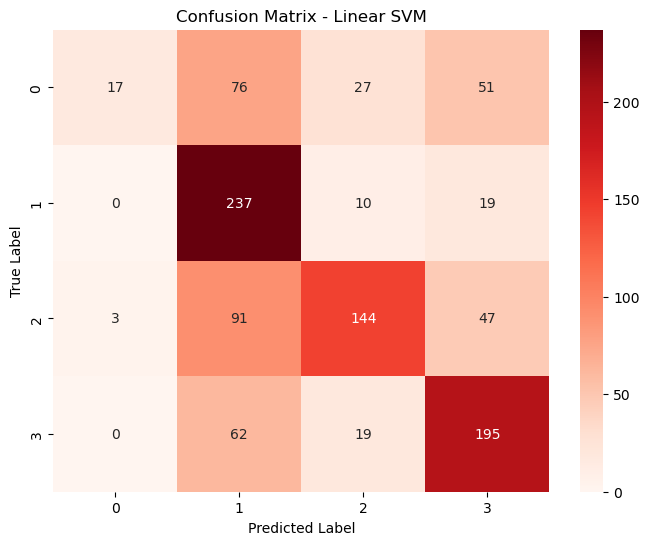

======= Evaluasi Klasifikasi Linear SVM =======
Akurasi Klasifikasi     : 59.42%
F-measure (macro avg)   : 0.521
AUC rata-rata (macro)   : 0.879


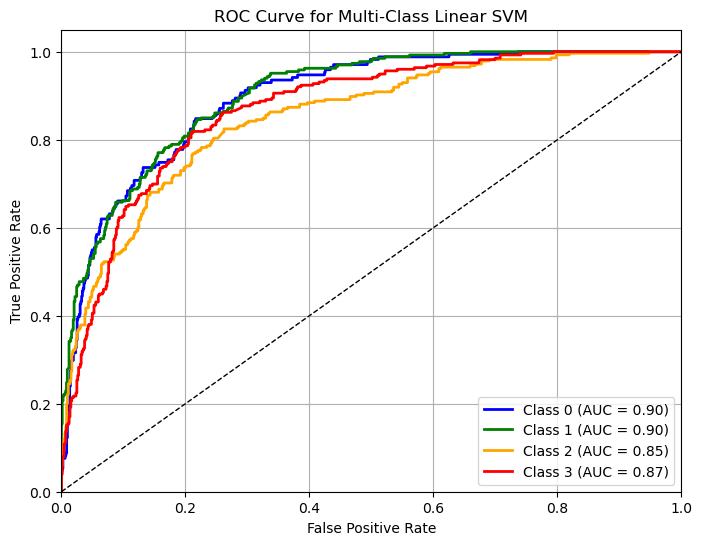

In [34]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Inisialisasi LinearSVC
linear_svm = LinearSVC(
    C=1.0,
    random_state=42,
    max_iter=1000,
    dual=True,
    verbose=1
)

# Training model
linear_svm.fit(X_train, y_train)

# Calibrasi untuk probability estimates
print("Calibrating probabilities...")
calibrated_svm = CalibratedClassifierCV(linear_svm, method='sigmoid', cv=3)
calibrated_svm.fit(X_train, y_train)

# Prediksi
y_pred_svm = calibrated_svm.predict(X_test)

# Evaluasi
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Evaluasi lengkap dengan ROC Curve
svm_results = evaluate_model(calibrated_svm, X_test, y_test, model_name="Linear SVM")

In [35]:
new_text = ["this is bad product"]

# Preprocessing dulu jika diperlukan, lalu transform
X_new = tfidf.transform(new_text)

# Prediksi sentimen
pred = model.predict(X_new)
print("Hasil Prediksi:", pred[0])

Hasil Prediksi: Negative


In [36]:
new_text = ["good"]

# Preprocessing dulu jika diperlukan, lalu transform
X_new = tfidf.transform(new_text)

# Prediksi sentimen
pred = model.predict(X_new)
print("Hasil Prediksi:", pred[0])

Hasil Prediksi: Positive


Accuracy: 0.5280561122244489
Classification Report:
               precision    recall  f1-score   support

  Irrelevant       0.86      0.04      0.07       171
    Negative       0.42      0.91      0.58       266
     Neutral       0.84      0.35      0.50       285
    Positive       0.60      0.64      0.62       276

    accuracy                           0.53       998
   macro avg       0.68      0.49      0.44       998
weighted avg       0.67      0.53      0.48       998



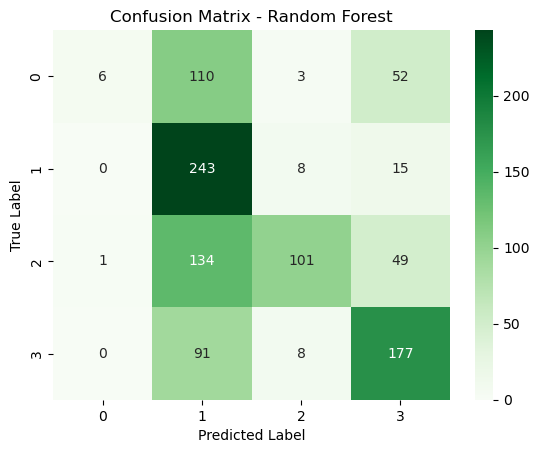

======= Evaluasi Klasifikasi Random Forest =======
Akurasi Klasifikasi     : 52.81%
F-measure (macro avg)   : 0.441
AUC rata-rata (macro)   : 0.858


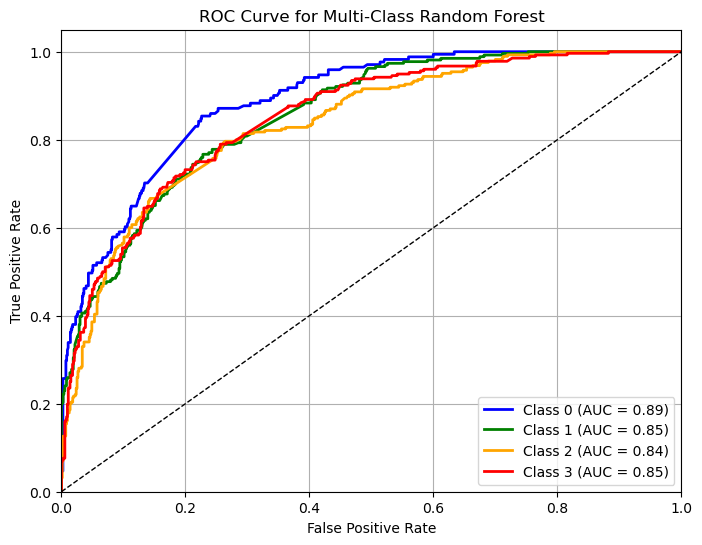

In [37]:
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,       
    max_depth=20,          
    min_samples_split=5,    
    min_samples_leaf=2,     
    random_state=42,        
    n_jobs=-1               
)

# Training model
rf_model.fit(X_train, y_train)

# Prediksi
y_pred_rf = rf_model.predict(X_test)

# Evaluasi
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Evaluasi lengkap dengan ROC Curve
rf_results = evaluate_model(rf_model, X_test, y_test, model_name="Random Forest")

In [38]:
new_text = ["this is a good product"]

# Preprocessing dulu jika diperlukan, lalu transform
X_new = tfidf.transform(new_text)

# Prediksi sentimen
pred = model.predict(X_new)
print("Hasil Prediksi:", pred[0])

Hasil Prediksi: Positive


In [39]:
new_text = ["good"]

# Preprocessing dulu jika diperlukan, lalu transform
X_new = tfidf.transform(new_text)

# Prediksi sentimen
pred = model.predict(X_new)
print("Hasil Prediksi:", pred[0])

Hasil Prediksi: Positive


[LibLinear]Calibrating probabilities...
[LibLinear][LibLinear]Accuracy: 0.594188376753507
Classification Report:
               precision    recall  f1-score   support

  Irrelevant       0.85      0.10      0.18       171
    Negative       0.51      0.89      0.65       266
     Neutral       0.72      0.51      0.59       285
    Positive       0.62      0.71      0.66       276

    accuracy                           0.59       998
   macro avg       0.68      0.55      0.52       998
weighted avg       0.66      0.59      0.56       998



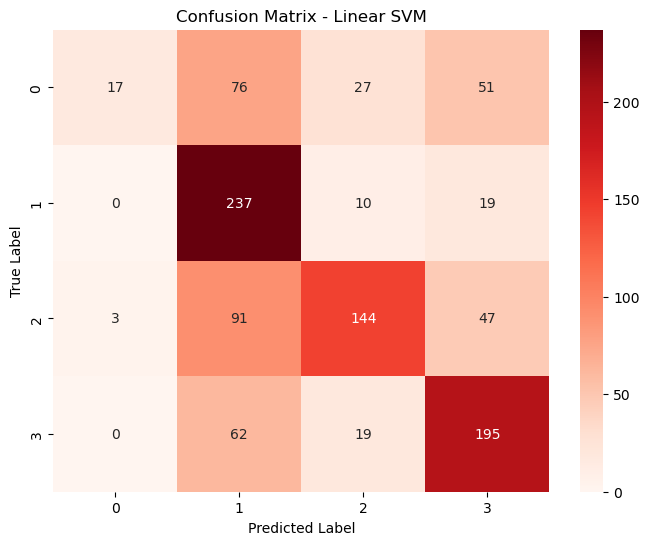

======= Evaluasi Klasifikasi Linear SVM =======
Akurasi Klasifikasi     : 59.42%
F-measure (macro avg)   : 0.521
AUC rata-rata (macro)   : 0.879


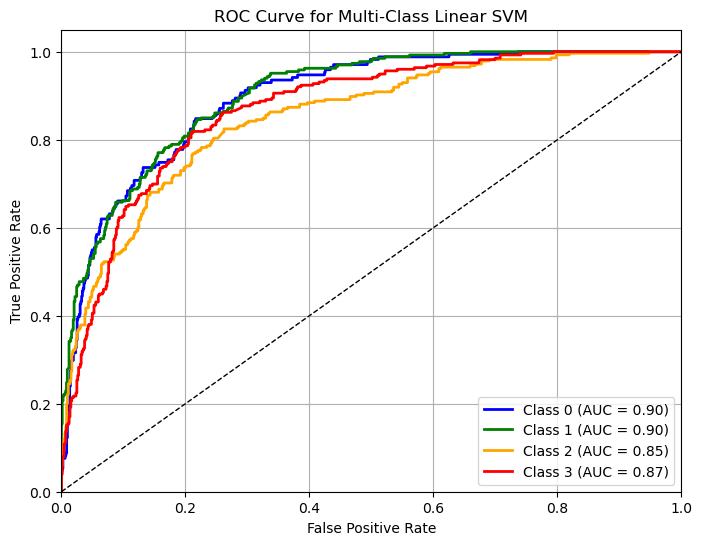

In [40]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Inisialisasi LinearSVC
linear_svm = LinearSVC(
    C=1.0,
    random_state=42,
    max_iter=1000,
    dual=True,
    verbose=1
)

# Training model
linear_svm.fit(X_train, y_train)

# Calibrasi untuk probability estimates
print("Calibrating probabilities...")
calibrated_svm = CalibratedClassifierCV(linear_svm, method='sigmoid', cv=3)
calibrated_svm.fit(X_train, y_train)

# Prediksi
y_pred_svm = calibrated_svm.predict(X_test)

# Evaluasi
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Evaluasi lengkap dengan ROC Curve
svm_results = evaluate_model(calibrated_svm, X_test, y_test, model_name="Linear SVM")

In [41]:
new_text = ["this is a good product"]

# Preprocessing dulu jika diperlukan, lalu transform
X_new = tfidf.transform(new_text)

# Prediksi sentimen
pred = model.predict(X_new)
print("Hasil Prediksi:", pred[0])

Hasil Prediksi: Positive


In [42]:
new_text = ["good"]

# Preprocessing dulu jika diperlukan, lalu transform
X_new = tfidf.transform(new_text)

# Prediksi sentimen
pred = model.predict(X_new)
print("Hasil Prediksi:", pred[0])

Hasil Prediksi: Positive


In [46]:
!pip install xgboost


In [ ]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Encode labels ke numerik
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Cek mapping label
print("Label mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# Inisialisasi dan training XGBoost
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss'
)

# Training dengan encoded labels
xgb_model.fit(X_train, y_train_encoded)

# Prediksi
y_pred_xgb_encoded = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)

# Convert kembali ke label asli untuk reporting
y_pred_xgb_original = label_encoder.inverse_transform(y_pred_xgb_encoded)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb_original))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb_original))

# Confusion Matrix dengan label asli
cm_xgb = confusion_matrix(y_test, y_pred_xgb_original)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues", 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Evaluasi lengkap manual
print("======= Evaluasi XGBoost =======")
accuracy = accuracy_score(y_test, y_pred_xgb_original)
f1_macro = f1_score(y_test, y_pred_xgb_original, average='macro')

# Hitung AUC
y_test_bin = label_binarize(y_test_encoded, classes=np.unique(y_test_encoded))
auc_macro = roc_auc_score(y_test_bin, y_proba_xgb, average="macro", multi_class="ovr")

print(f"Akurasi Klasifikasi     : {accuracy * 100:.2f}%")
print(f"F-measure (macro avg)   : {f1_macro:.3f}")
print(f"AUC rata-rata (macro)   : {auc_macro:.3f}")
print("=" * 45)

# ROC Curve untuk tiap kelas
plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'orange', 'red', 'purple', 'brown']

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(label_encoder.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba_xgb[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    class_name = label_encoder.inverse_transform([i])[0]
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'{class_name} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Simpan results
xgb_results = {
    "model": "XGBoost",
    "accuracy": accuracy,
    "f1_macro": f1_macro,
    "auc_macro": auc_macro
}

print("XGBoost Results:", xgb_results)

Label mapping: {'Irrelevant': np.int64(0), 'Negative': np.int64(1), 'Neutral': np.int64(2), 'Positive': np.int64(3)}


In [ ]:
new_text = ["this is a good product"]

# Preprocessing dulu jika diperlukan, lalu transform
X_new = tfidf.transform(new_text)

# Prediksi sentimen
pred = model.predict(X_new)
print("Hasil Prediksi:", pred[0])

In [ ]:
new_text = ["good"]

# Preprocessing dulu jika diperlukan, lalu transform
X_new = tfidf.transform(new_text)

# Prediksi sentimen
pred = model.predict(X_new)
print("Hasil Prediksi:", pred[0])

In [ ]:
new_text = ["this is a good product"]

# Preprocessing dengan TF-IDF yang sama
X_new = tfidf.transform(new_text)

# Prediksi dengan model yang berbeda
pred_lr = model.predict(X_new)          # Logistic Regression
pred_rf = rf_model.predict(X_new)          # Random Forest  
pred_svm = calibrated_svm.predict(X_new)   # SVM
pred_xgb = xgb_model.predict(X_new)        # XGBoost

print("Hasil Prediksi Logistic Regression:", pred_lr[0])
print("Hasil Prediksi Random Forest:", pred_rf[0])
print("Hasil Prediksi SVM:", pred_svm[0])
print("Hasil Prediksi XGBoost:", pred_xgb[0])

In [ ]:
new_text = ["this is a bad product"]

# Preprocessing dengan TF-IDF yang sama
X_new = tfidf.transform(new_text)

# Prediksi dengan model yang berbeda
pred_lr = model.predict(X_new)          # Logistic Regression
pred_rf = rf_model.predict(X_new)          # Random Forest  
pred_svm = calibrated_svm.predict(X_new)   # SVM
pred_xgb = xgb_model.predict(X_new)        # XGBoost

print("Hasil Prediksi Logistic Regression:", pred_lr[0])
print("Hasil Prediksi Random Forest:", pred_rf[0])
print("Hasil Prediksi SVM:", pred_svm[0])
print("Hasil Prediksi XGBoost:", pred_xgb[0])

In [ ]:
new_text = ["This product is absolutely amazing and works perfectly!"]

# Preprocessing dengan TF-IDF yang sama
X_new = tfidf.transform(new_text)

# Prediksi dengan model yang berbeda
pred_lr = model.predict(X_new)          # Logistic Regression
pred_rf = rf_model.predict(X_new)          # Random Forest  
pred_svm = calibrated_svm.predict(X_new)   # SVM
pred_xgb = xgb_model.predict(X_new)        # XGBoost

print("Hasil Prediksi Logistic Regression:", pred_lr[0])
print("Hasil Prediksi Random Forest:", pred_rf[0])
print("Hasil Prediksi SVM:", pred_svm[0])
print("Hasil Prediksi XGBoost:", pred_xgb[0])

In [ ]:
pip freeze > requirements.txt